In [ ]:
!pip install transformers datasets scikit-learn sentencepiece accelerate joblib

Import Relevant Libraries

In [ ]:
import pandas as pd
import torch
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

Load Dataset

In [ ]:
df=pd.read_csv('Category.csv')

Load Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
df['category'].value_counts()

,count
category,
Constructive,3170
Others,1306
Cyberbullying,641
Irony,513
Offensive,278
Harmful,103


Training per Category

In [ ]:
def train_and_evaluate(category):

    print("\n============================")
    print("Training model for:", category)
    print("============================")

    cat_df = df[df["category"] == category].copy()

    # -------------------------
    # Encode labels
    # -------------------------

    le = LabelEncoder()
    cat_df["label"] = le.fit_transform(cat_df["subcategory"])

    # -------------------------
    # Train/Test Split
    # -------------------------

    if cat_df["label"].value_counts().min() < 2:

        print("Using random split")

        train_df, test_df = train_test_split(
            cat_df,
            test_size=0.2,
            random_state=42
        )

    else:

        train_df, test_df = train_test_split(
            cat_df,
            test_size=0.2,
            stratify=cat_df["label"],
            random_state=42
        )

    # -------------------------
    # Convert to HF Dataset
    # -------------------------

    train_dataset = Dataset.from_pandas(
        train_df[["text","label"]].reset_index(drop=True)
    )

    test_dataset = Dataset.from_pandas(
        test_df[["text","label"]].reset_index(drop=True)
    )

    # -------------------------
    # Tokenization
    # -------------------------

    def tokenize(batch):

        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=128
        )

    train_dataset = train_dataset.map(tokenize, batched=True)
    test_dataset = test_dataset.map(tokenize, batched=True)

    train_dataset.set_format(
        type="torch",
        columns=["input_ids","attention_mask","label"]
    )

    test_dataset.set_format(
        type="torch",
        columns=["input_ids","attention_mask","label"]
    )

    # -------------------------
    # Load Transformer Model
    # -------------------------

    model = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base",
        num_labels=len(le.classes_)
    )

    # -------------------------
    # Training Arguments
    # -------------------------

    training_args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    # -------------------------
    # Train
    # -------------------------

    trainer.train()

    # -------------------------
    # Evaluate
    # -------------------------

    predictions = trainer.predict(test_dataset)

    preds = np.argmax(predictions.predictions, axis=1)
    labels = predictions.label_ids

    # -------------------------
    # Metrics
    # -------------------------

    acc = accuracy_score(labels, preds)

    macro_f1 = f1_score(labels, preds, average="macro")

    weighted_f1 = f1_score(labels, preds, average="weighted")

    print("\nAccuracy:", acc)

    print("Macro F1:", macro_f1)

    print("Weighted F1:", weighted_f1)

    # -------------------------
    # Classification Report
    # -------------------------

    print("\nClassification Report\n")

    print(
        classification_report(
            labels,
            preds,
            labels=range(len(le.classes_)),
            target_names=le.classes_,
            zero_division=0
        )
    )

    # -------------------------
    # Confusion Matrix
    # -------------------------

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {category}")

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.show()

    # -------------------------
    # Save Model
    # -------------------------

    save_path = f"models/{category}_sub_model"

    os.makedirs(save_path, exist_ok=True)

    trainer.save_model(save_path)

    tokenizer.save_pretrained(save_path)

    joblib.dump(le, f"{save_path}/label_encoder.pkl")

    print("\nModel saved:", save_path)

## Train Constructive Category


Training model for: Irony
Using random split


Map:   0%|          | 0/410 [00:00<?, ? examples/s]

Map:   0%|          | 0/103 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,1.320976
2,1.409528,1.343046
3,1.409528,1.235363



Accuracy: 0.6116504854368932
Macro F1: 0.17198879551820728
Weighted F1: 0.510375023795926

Classification Report

                                 precision    recall  f1-score   support

                   Body shaming       0.00      0.00      0.00         0
                  Direct Insult       0.00      0.00      0.00         1
              Exclusion tactics       0.00      0.00      0.00         1
                 General Others       0.00      0.00      0.00         0
                    Humiliation       0.00      0.00      0.00         0
      Hyperbolic understatement       0.00      0.00      0.00         9
Misleading/Contextual Deception       0.00      0.00      0.00         0
                  Mock Laughter       1.00      0.31      0.47        26
                Mock compliment       0.58      1.00      0.73        55
            Rhetorical Question       0.00      0.00      0.00         9
              Supportive Speech       0.00      0.00      0.00         2

       

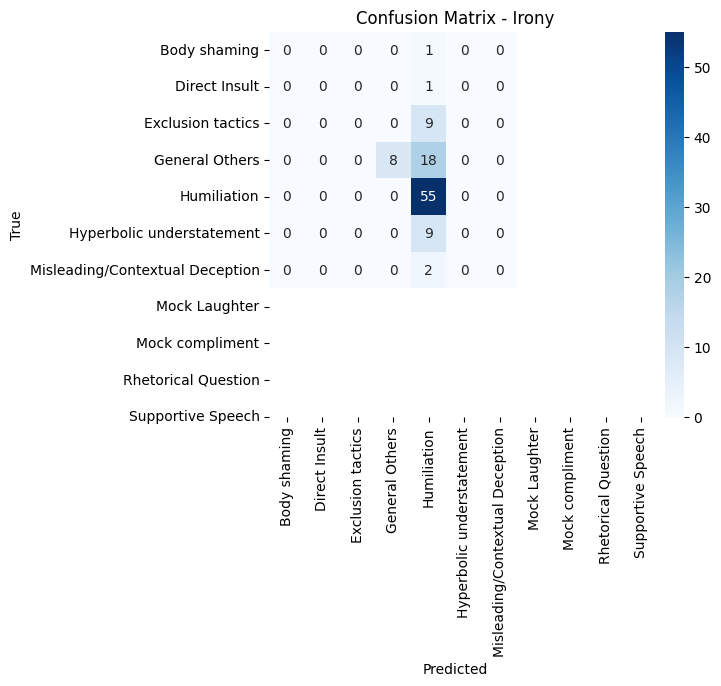

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved: models/Irony_sub_model


In [ ]:
train_and_evaluate("Irony")


Training model for: Cyberbullying
Using random split


Map:   0%|          | 0/512 [00:00<?, ? examples/s]

Map:   0%|          | 0/129 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,1.875697
2,2.154547,1.844573
3,2.154547,1.840078



Accuracy: 0.3023255813953488
Macro F1: 0.06790530416541804
Weighted F1: 0.21378808891614573

Classification Report

                                 precision    recall  f1-score   support

                   Body shaming       0.00      0.00      0.00         9
       Corrective clarification       0.00      0.00      0.00         0
             Decision-criticism       0.00      0.00      0.00         0
                     Defamation       0.00      0.00      0.00         7
                  Direct Insult       0.29      0.79      0.43        38
              Exclusion tactics       0.00      0.00      0.00         2
                   Gender based       0.00      0.00      0.00         2
                    Humiliation       0.35      0.20      0.25        45
Misleading/Contextual Deception       0.00      0.00      0.00         0
              Performance-based       0.00      0.00      0.00         0
                      Political       0.00      0.00      0.00         0
      

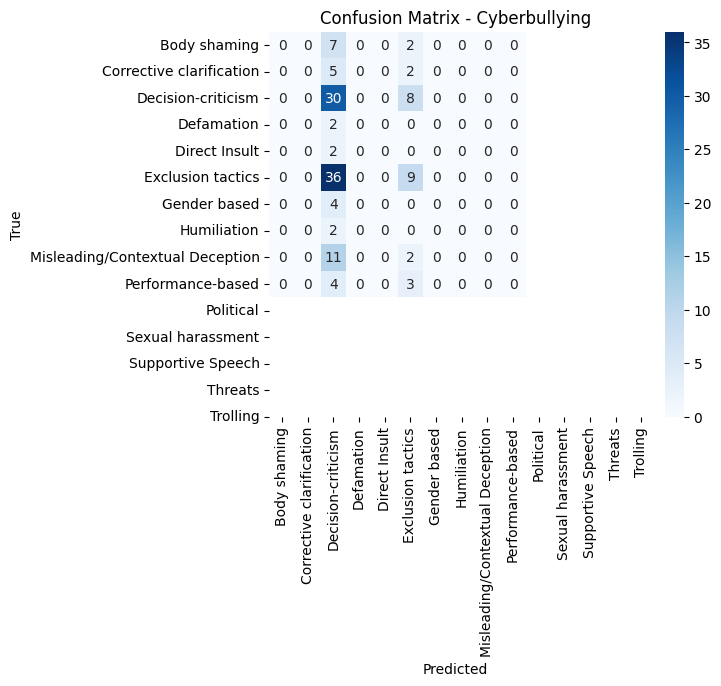

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved: models/Cyberbullying_sub_model


In [ ]:
train_and_evaluate("Cyberbullying")


Training model for: Others
Using random split


Map:   0%|          | 0/1044 [00:00<?, ? examples/s]

Map:   0%|          | 0/262 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.859066,0.672808
2,0.572861,0.673047
3,0.498633,0.640066



Accuracy: 0.816793893129771
Macro F1: 0.14985994397759103
Weighted F1: 0.7344281223939957

Classification Report

                                 precision    recall  f1-score   support

             Decision-criticism       0.00      0.00      0.00         0
                     Defamation       0.00      0.00      0.00         0
              Exclusion tactics       0.00      0.00      0.00         0
                General Inquiry       0.00      0.00      0.00        37
                 General Others       0.82      1.00      0.90       214
                 Genuine Praise       0.00      0.00      0.00         0
               Genuine feedback       0.00      0.00      0.00         1
Misleading/Contextual Deception       0.00      0.00      0.00         1
                Mock compliment       0.00      0.00      0.00         0
                   Non-personal       0.00      0.00      0.00         0
            Rhetorical Question       0.00      0.00      0.00         0
        

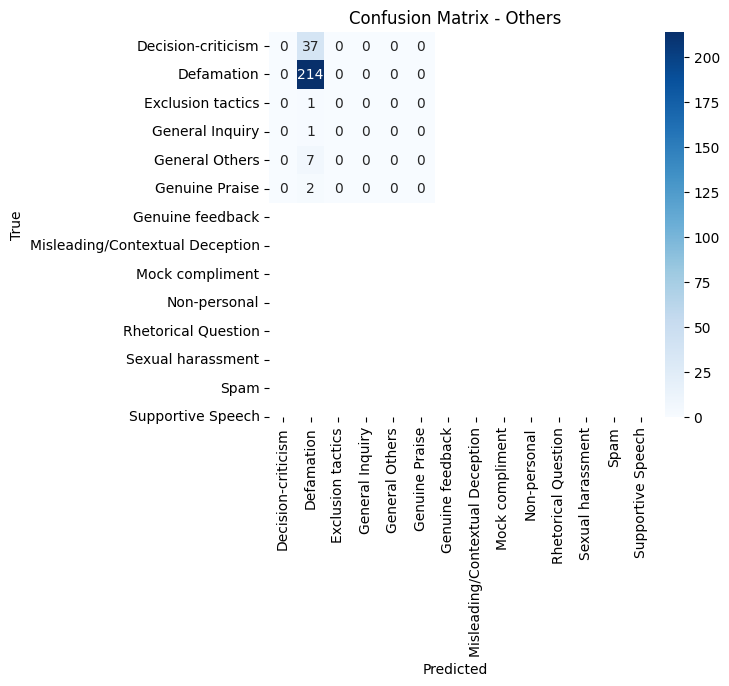

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved: models/Others_sub_model


In [ ]:
train_and_evaluate("Others")


Training model for: Offensive
Using random split


Map:   0%|          | 0/222 [00:00<?, ? examples/s]

Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,1.304268
2,No log,1.188829
3,No log,1.200505



Accuracy: 0.48214285714285715
Macro F1: 0.13012048192771083
Weighted F1: 0.31368330464716004

Classification Report

                          precision    recall  f1-score   support

Corrective clarification       0.00      0.00      0.00         2
      Decision-criticism       0.00      0.00      0.00         0
           Direct Insult       0.00      0.00      0.00         0
          General Others       0.00      0.00      0.00         0
          Genuine Praise       0.00      0.00      0.00         0
             Humiliation       0.00      0.00      0.00         0
            Non-personal       0.00      0.00      0.00        22
       Performance-based       0.00      0.00      0.00         1
               Sex-based       0.00      0.00      0.00         4
       Supportive Speech       0.00      0.00      0.00         0
                Trolling       0.00      0.00      0.00         0
Vulgar language (Matusi)       0.48      1.00      0.65        27

                accura

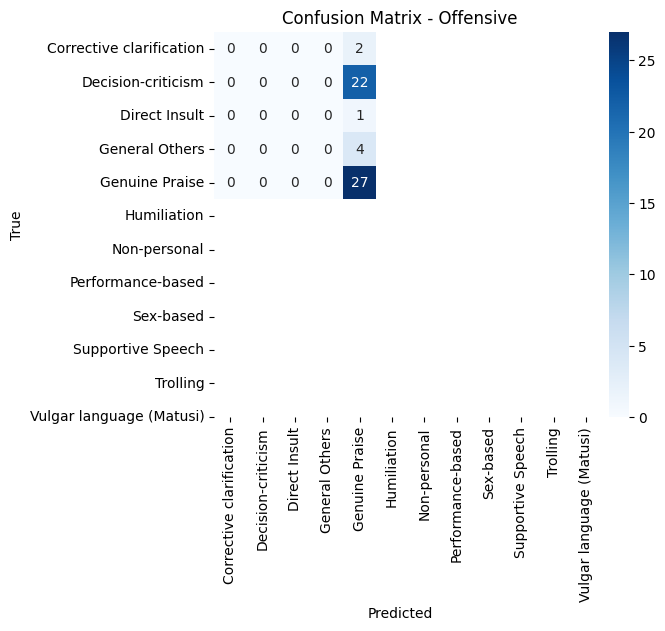

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved: models/Offensive_sub_model


In [ ]:
train_and_evaluate("Offensive")


Training model for: Harmful
Using random split


Map:   0%|          | 0/82 [00:00<?, ? examples/s]

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,2.385257
2,No log,2.184328
3,No log,2.039891



Accuracy: 0.5238095238095238
Macro F1: 0.0763888888888889
Weighted F1: 0.3601190476190476

Classification Report

                                  precision    recall  f1-score   support

        Corrective clarification       0.00      0.00      0.00         1
              Decision-criticism       0.00      0.00      0.00         1
                      Disability       0.00      0.00      0.00         0
Ethical/racial group (Tribalism)       0.00      0.00      0.00         2
  Fabricated Content (Fake News)       0.00      0.00      0.00         1
                    Gender based       0.00      0.00      0.00         2
                  General Others       0.00      0.00      0.00         0
                  Genuine Praise       0.00      0.00      0.00         0
                     Humiliation       0.00      0.00      0.00         0
 Misleading/Contextual Deception       0.52      1.00      0.69        11
                    Non-personal       0.00      0.00      0.00       

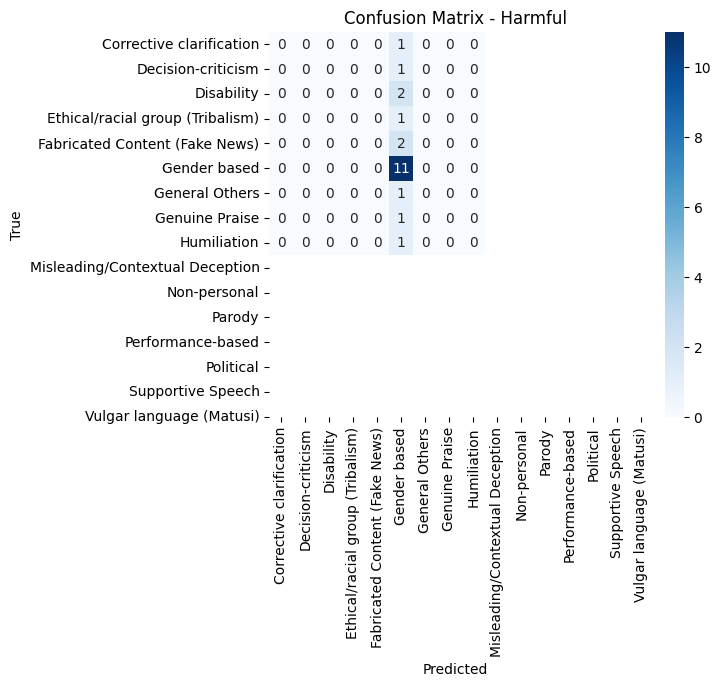

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved: models/Harmful_sub_model


In [ ]:
train_and_evaluate("Harmful")


Training model for: Constructive
Using random split


Map:   0%|          | 0/2536 [00:00<?, ? examples/s]

Map:   0%|          | 0/634 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,1.692228,1.659788
2,1.653573,1.611455
3,1.581246,1.612598



Accuracy: 0.3864353312302839
Macro F1: 0.1688860818791877
Weighted F1: 0.31030757852165947

Classification Report

                          precision    recall  f1-score   support

            Body shaming       0.00      0.00      0.00         0
Corrective clarification       0.00      0.00      0.00        55
      Decision-criticism       0.33      0.55      0.41        92
           Direct Insult       0.00      0.00      0.00         0
            Gender based       0.00      0.00      0.00         3
         General Inquiry       0.00      0.00      0.00         0
          General Others       0.00      0.00      0.00         1
          Genuine Praise       0.45      0.45      0.45       111
        Genuine feedback       0.00      0.00      0.00        65
             Humiliation       0.00      0.00      0.00         0
            Non-personal       0.00      0.00      0.00         0
       Performance-based       0.00      0.00      0.00        84
       Supportive Speech 

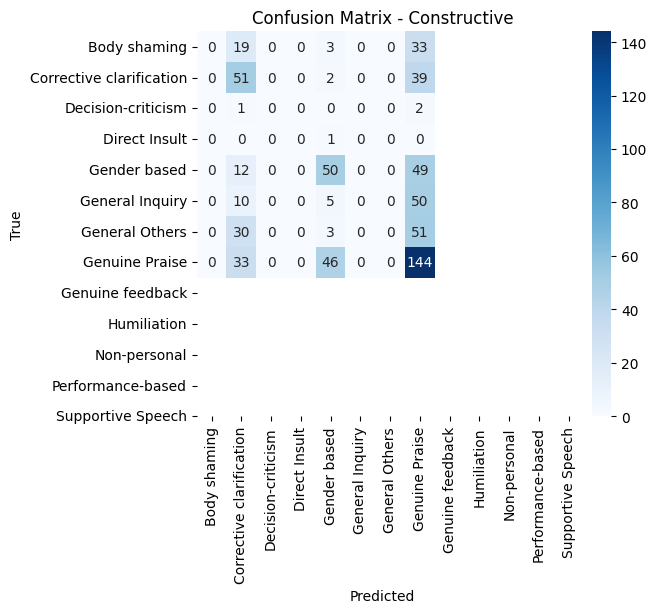

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved: models/Constructive_sub_model


In [ ]:
train_and_evaluate("Constructive")

In [ ]:
import pandas as pd
import torch
import joblib
import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [ ]:
df = pd.read_csv("Category.csv")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

models = {
    "Irony": AutoModelForSequenceClassification.from_pretrained(
        "models/Irony_sub_model"
    ).to(device),

    "Others": AutoModelForSequenceClassification.from_pretrained(
        "models/Others_sub_model"
    ).to(device),

    "Constructive": AutoModelForSequenceClassification.from_pretrained(
        "models/Constructive_sub_model"
    ).to(device),

    "Cyberbullying": AutoModelForSequenceClassification.from_pretrained(
        "models/Cyberbullying_sub_model"
    ).to(device),

    "Offensive": AutoModelForSequenceClassification.from_pretrained(
        "models/Offensive_sub_model"
    ).to(device),

    "Harmful": AutoModelForSequenceClassification.from_pretrained(
        "models/Harmful_sub_model"
    ).to(device)
}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
encoders = {
    "Irony": joblib.load("models/Irony_sub_model/label_encoder.pkl"),
    "Others": joblib.load("models/Others_sub_model/label_encoder.pkl"),
    "Constructive": joblib.load("models/Constructive_sub_model/label_encoder.pkl"),
    "Cyberbullying": joblib.load("models/Cyberbullying_sub_model/label_encoder.pkl"),
    "Offensive": joblib.load("models/Offensive_sub_model/label_encoder.pkl"),
    "Harmful": joblib.load("models/Harmful_sub_model/label_encoder.pkl")
}

In [ ]:
def predict_subcategory(text, category):

    model = models[category]
    encoder = encoders[category]

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits).item()

    return encoder.inverse_transform([pred_id])[0]

In [ ]:
y_true = []
y_pred = []

for _, row in df.iterrows():

    text = row["text"]
    category = row["category"]
    true_sub = row["subcategory"]

    pred_sub = predict_subcategory(text, category)

    y_true.append(true_sub)
    y_pred.append(pred_sub)

In [ ]:
print("Overall Accuracy:",
      accuracy_score(y_true, y_pred))

print("Macro F1:",
      f1_score(y_true, y_pred, average="macro"))

print("Weighted F1:",
      f1_score(y_true, y_pred, average="weighted"))

Overall Accuracy: 0.5170520712027948
Macro F1: 0.17980480262119106
Weighted F1: 0.42868904865298274


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)

                                  precision    recall  f1-score   support

                    Body shaming       0.00      0.00      0.00        59
        Corrective clarification       0.00      0.00      0.00       280
              Decision-criticism       0.32      0.59      0.42       460
                      Defamation       0.00      0.00      0.00        61
                   Direct Insult       0.33      0.84      0.48       204
                      Disability       0.00      0.00      0.00         2
Ethical/racial group (Tribalism)       0.00      0.00      0.00        10
               Exclusion tactics       0.00      0.00      0.00        24
  Fabricated Content (Fake News)       0.00      0.00      0.00         4
                    Gender based       0.00      0.00      0.00        34
                 General Inquiry       0.00      0.00      0.00       166
                  General Others       0.84      0.99      0.91      1106
                  Genuine Praise     

In [ ]:
!ls models

Constructive_sub_model	 Harmful_sub_model  Offensive_sub_model
Cyberbullying_sub_model  Irony_sub_model    Others_sub_model


In [ ]:
!ls models

Constructive_sub_model	 Harmful_sub_model  Offensive_sub_model
Cyberbullying_sub_model  Irony_sub_model    Others_sub_model


In [ ]:
!zip -r subcategory_models.zip models

In [ ]:
from google.colab import files
files.download("subcategory_models.zip")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Replace 'My Drive/folder_name/...' with the actual folder path in your Drive
!cp "/content/drive/My Drive/subcategory_models.zip" /content/

In [ ]:
# This copies the file to the root of your 'My Drive' folder
!cp /content/subcategory_models.zip "/content/drive/My Drive/"

In [ ]:
!ls "/content/drive/My Drive/"